In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression

from sklearn.neighbors import KNeighborsClassifier

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [2]:
iris = load_iris()

df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

df["Species"] = iris.target

df["Species"] = df["Species"].map({
    0:"Setosa",
    1:"Versicolor",
    2:"Virginica"
})

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Species
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   Species            150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB


In [4]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [5]:
df.shape

(150, 5)

In [6]:
df.isnull().sum()

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
Species              0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(1)

In [8]:
df["Species"].value_counts()

Species
Setosa        50
Versicolor    50
Virginica     50
Name: count, dtype: int64

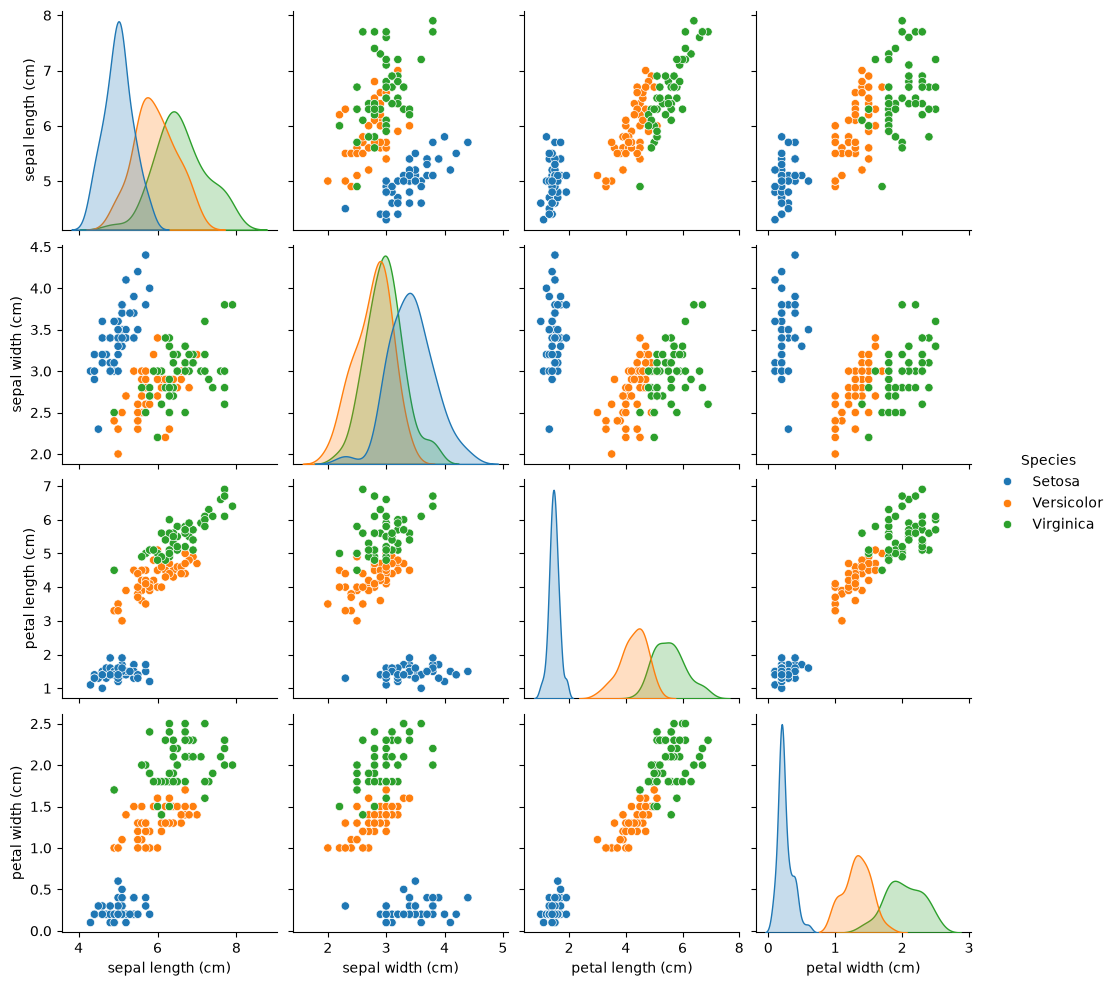

In [9]:
sns.pairplot(
    df,
    hue="Species"
)

plt.show()

In [10]:
plt.savefig("outputs/pairplot.png")

FileNotFoundError: [Errno 2] No such file or directory: 'outputs/pairplot.png'

<Figure size 640x480 with 0 Axes>

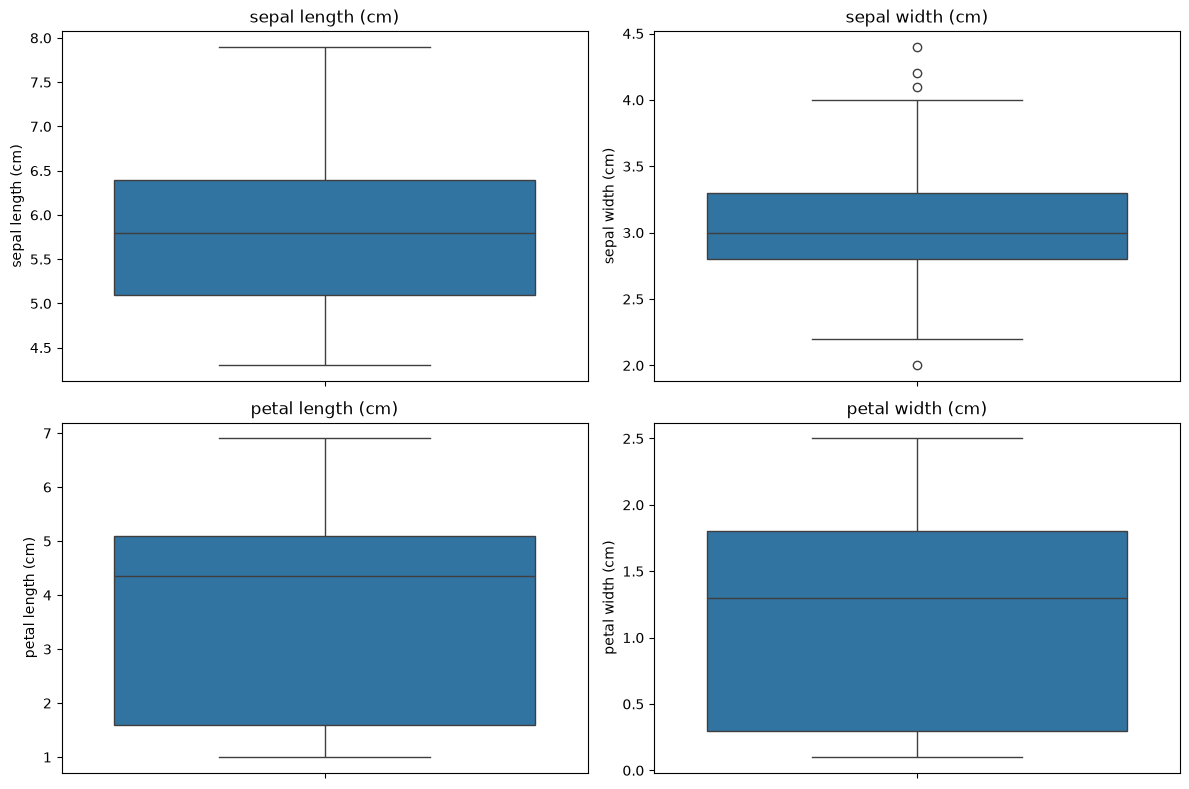

In [11]:
plt.figure(figsize=(12,8))

for i,column in enumerate(df.columns[:-1]):
    
    plt.subplot(2,2,i+1)
    
    sns.boxplot(
        y=df[column]
    )
    
    plt.title(column)

plt.tight_layout()

plt.show()

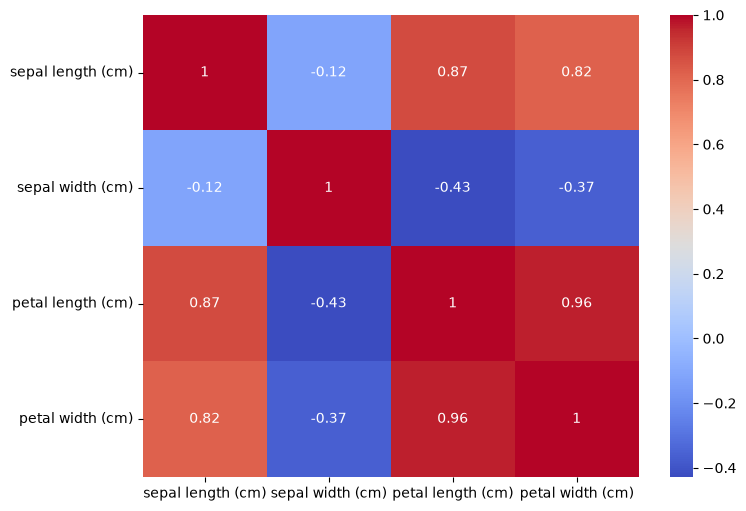

In [12]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.iloc[:,:-1].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.show()

In [13]:
X = df.drop("Species",axis=1)

y = df["Species"]

In [14]:
X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [15]:
lr=LogisticRegression()

lr.fit(X_train,y_train)

lr_pred=lr.predict(X_test)

lr_accuracy=accuracy_score(
    y_test,
    lr_pred
)

print(lr_accuracy)

1.0


In [16]:
knn=KNeighborsClassifier()

knn.fit(X_train,y_train)

knn_pred=knn.predict(X_test)

knn_accuracy=accuracy_score(
    y_test,
    knn_pred
)

print(knn_accuracy)

1.0


In [17]:
dt=DecisionTreeClassifier()

dt.fit(X_train,y_train)

dt_pred=dt.predict(X_test)

dt_accuracy=accuracy_score(
    y_test,
    dt_pred
)

print(dt_accuracy)

1.0


In [18]:
rf=RandomForestClassifier()

rf.fit(X_train,y_train)

rf_pred=rf.predict(X_test)

rf_accuracy=accuracy_score(
    y_test,
    rf_pred
)

print(rf_accuracy)

1.0


In [19]:
models=["Logistic","KNN","Decision Tree","Random Forest"]

accuracy=[
    lr_accuracy,
    knn_accuracy,
    dt_accuracy,
    rf_accuracy
]

result=pd.DataFrame({
    "Model":models,
    "Accuracy":accuracy
})

result

,Model,Accuracy
0,Logistic,1.0
1,KNN,1.0
2,Decision Tree,1.0
3,Random Forest,1.0


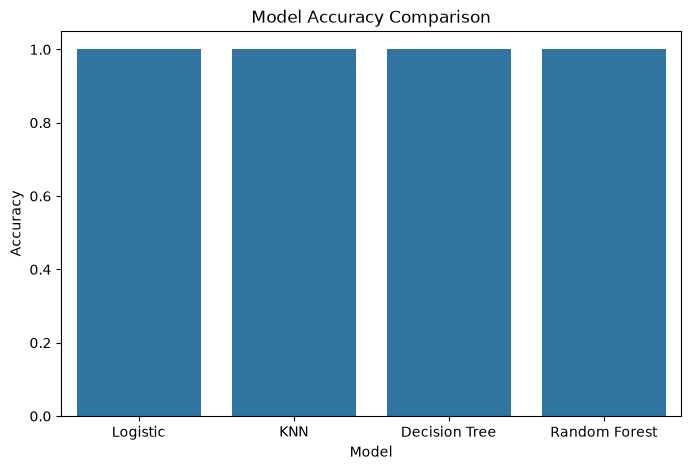

In [20]:
plt.figure(figsize=(8,5))

sns.barplot(
    x="Model",
    y="Accuracy",
    data=result
)

plt.title("Model Accuracy Comparison")

plt.show()

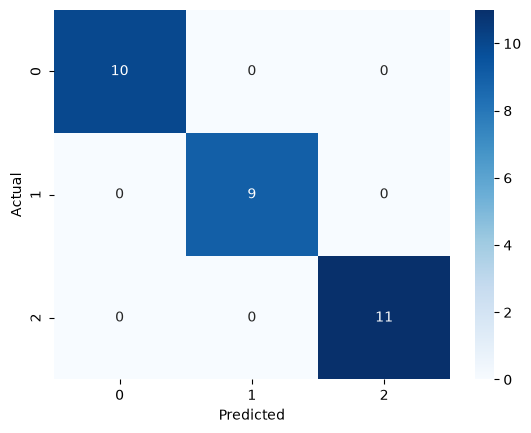

In [21]:
cm=confusion_matrix(
    y_test,
    rf_pred
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [22]:
print(
classification_report(
y_test,
rf_pred
)
)

              precision    recall  f1-score   support

      Setosa       1.00      1.00      1.00        10
  Versicolor       1.00      1.00      1.00         9
   Virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [23]:
print(result)

           Model  Accuracy
0       Logistic       1.0
1            KNN       1.0
2  Decision Tree       1.0
3  Random Forest       1.0
